In [4]:
import pandas as pd

In [2]:
#주가데이터.xlsx파일을 df데이터프레임 객체로 저장하기
df=pd.read_excel("주가데이터.xlsx")
df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   연월일     20 non-null     datetime64[us]
 1   당일종가    20 non-null     int64         
 2   전일종가    20 non-null     int64         
 3   시가      20 non-null     int64         
 4   고가      20 non-null     int64         
 5   저가      20 non-null     int64         
 6   거래량     20 non-null     int64         
dtypes: datetime64[us](1), int64(6)
memory usage: 1.2 KB


In [3]:
#연월일 컬럼에서 년,월,일 컬럼을 생성하기
df['년'] = df['연월일'].dt.year
df['월'] = df['연월일'].dt.month
df['일'] = df['연월일'].dt.day
df

,연월일,당일종가,전일종가,시가,고가,저가,거래량,년,월,일
0,2018-07-02,10100,600,10850,10900,10000,137977,2018,7,2
1,2018-06-29,10700,300,10550,10900,9990,170253,2018,6,29
2,2018-06-28,10400,500,10900,10950,10150,155769,2018,6,28
3,2018-06-27,10900,100,10800,11050,10500,133548,2018,6,27
4,2018-06-26,10800,350,10900,11000,10700,63039,2018,6,26
5,2018-06-25,11150,150,11400,11450,11000,55519,2018,6,25
6,2018-06-22,11300,100,11250,11450,10750,134805,2018,6,22
7,2018-06-21,11200,350,11350,11750,11200,133002,2018,6,21
8,2018-06-20,11550,250,11200,11600,10900,308596,2018,6,20
9,2018-06-19,11300,700,11850,11950,11300,180656,2018,6,19


In [4]:
#DataFrame.to_datetime : str 컬럼을 datetime 컬럼으로 변경
#형변환 astype() : datetime 컬럼을 str 타입의 컬럼으로 변경
# 연월일 컬럼을 str타입의 연월일2 컬럼으로 변경해서 컬럼 추가하기
df['연월일2'] = df["연월일"].astype('str')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   연월일     20 non-null     datetime64[us]
 1   당일종가    20 non-null     int64         
 2   전일종가    20 non-null     int64         
 3   시가      20 non-null     int64         
 4   고가      20 non-null     int64         
 5   저가      20 non-null     int64         
 6   거래량     20 non-null     int64         
 7   년       20 non-null     int32         
 8   월       20 non-null     int32         
 9   일       20 non-null     int32         
 10  연월일2    20 non-null     str           
dtypes: datetime64[us](1), int32(3), int64(6), str(1)
memory usage: 1.6 KB


In [7]:
#문자열 컬럼을 가공하기.yyyy-mm-dd => 문자열로 년2,월2,일2 컬럼 추가하기
dates = df["연월일2"].str.split('-')
dates
df['년2'] = dates.str.get(0)
df['월2'] = dates.str.get(1)
df['일2'] = dates.str.get(2)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   연월일     20 non-null     datetime64[us]
 1   당일종가    20 non-null     int64         
 2   전일종가    20 non-null     int64         
 3   시가      20 non-null     int64         
 4   고가      20 non-null     int64         
 5   저가      20 non-null     int64         
 6   거래량     20 non-null     int64         
 7   년       20 non-null     int32         
 8   월       20 non-null     int32         
 9   일       20 non-null     int32         
 10  연월일2    20 non-null     str           
 11  년2      20 non-null     object        
 12  월2      20 non-null     object        
 13  일2      20 non-null     object        
dtypes: datetime64[us](1), int32(3), int64(6), object(3), str(1)
memory usage: 2.1+ KB


In [ ]:
df

In [5]:
# 필터 : 조건에 맞는 데이터만 조회하기
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [14]:
#타이타닉승객중 10대 (10 ~ 19세)인 승객만 df_teenage 에 저장하기
mask1 = (titanic.age >= 10) & (titanic.age < 20)
#df_teenage = titanic[mask1]
df_teenage = titanic.loc[mask1,:]
df_teenage.info()

<class 'pandas.DataFrame'>
Index: 102 entries, 9 to 887
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     102 non-null    int64   
 1   pclass       102 non-null    int64   
 2   sex          102 non-null    str     
 3   age          102 non-null    float64 
 4   sibsp        102 non-null    int64   
 5   parch        102 non-null    int64   
 6   fare         102 non-null    float64 
 7   embarked     102 non-null    str     
 8   class        102 non-null    category
 9   who          102 non-null    str     
 10  adult_male   102 non-null    bool    
 11  deck         19 non-null     category
 12  embark_town  102 non-null    str     
 13  alive        102 non-null    str     
 14  alone        102 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 10.4 KB


In [ ]:
#sibsp 컬럼 : 동행자의 인원수 
titanic['sibsp'].unique()
#동행자 인원수가 3,4,5인 승객의 sibsp, alone 컬럼 조회하기
#mask2 = (titanic.sibsp == 3) | (titanic.sibsp == 4) | (titanic.sibsp == 5) 
#isin() :  컬럼의 값을 OR로 처리
mask2 = titanic.sibsp.isin([3,4,5])
df_notalone = titanic[['sibsp','alone']][mask2]
df_notalone.info()
df_notalone

In [ ]:
# class 컬럼 중 First, Second인 행만 조회하기
mask3 = titanic['class'].isin(['First','Second'])
df_class12 = titanic[mask3]
df_class12.info()
df_class12['class'].value_counts()

In [6]:
# groupby : 특정 컬럼을 기준으로 레코드들을 그룹화하기
# class 컬럼을 그룹화 하기
grouped = titanic.groupby('class')
for key,data in grouped :
    print("* key :",key)
    print("* len :", len(data))
    print(data.head())

* key : First
* len : 216
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1          1       1  female  38.0      1      0  71.2833        C  First   
3          1       1  female  35.0      1      0  53.1000        S  First   
6          0       1    male  54.0      0      0  51.8625        S  First   
11         1       1  female  58.0      0      0  26.5500        S  First   
23         1       1    male  28.0      0      0  35.5000        S  First   

      who  adult_male deck  embark_town alive  alone  
1   woman       False    C    Cherbourg   yes  False  
3   woman       False    C  Southampton   yes  False  
6     man        True    E  Southampton    no   True  
11  woman       False    C  Southampton   yes   True  
23    man        True    A  Southampton   yes   True  
* key : Second
* len : 184
    survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
9          1       2  female  14.0      1      0  30.0708        C  Second  

In [24]:
#  class 별 fare평균 요금
grouped['fare'].mean()


class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64

In [38]:
print(list(grouped.groups.keys()))

['First', 'Second', 'Third']


In [39]:
#3등석 정보만 가진 데이터만 df_class3 데이터에 저장하기
df_class3 = grouped.get_group('Third')
df_class3.info()

<class 'pandas.DataFrame'>
Index: 491 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     491 non-null    int64   
 1   pclass       491 non-null    int64   
 2   sex          491 non-null    str     
 3   age          355 non-null    float64 
 4   sibsp        491 non-null    int64   
 5   parch        491 non-null    int64   
 6   fare         491 non-null    float64 
 7   embarked     491 non-null    str     
 8   class        491 non-null    category
 9   who          491 non-null    str     
 10  adult_male   491 non-null    bool    
 11  deck         12 non-null     category
 12  embark_town  491 non-null    str     
 13  alive        491 non-null    str     
 14  alone        491 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 48.4 KB


In [44]:
# class 별 sex별로 그룹화하기
grouped2 = titanic.groupby(['class','sex'])
for key, data in grouped2 :
    print("* key:",key)
    print("* len :",len(data))

* key: ('First', 'female')
* len : 94
* key: ('First', 'male')
* len : 122
* key: ('Second', 'female')
* len : 76
* key: ('Second', 'male')
* len : 108
* key: ('Third', 'female')
* len : 144
* key: ('Third', 'male')
* len : 347


In [ ]:
#3등석 여성 승객 정보만 df_class3f데이터에 저장하기
df_class3f = grouped2.get_group(('Third','female'))
df_class3f.info()

In [ ]:
df_class3f.head()

In [ ]:
# agg() 함수 : 여러개의 함수를 여러개의 컬럼에 적용가능
def max_min(x) :
    return x.max() - x.min()

add_maxmin = grouped[['age','fare']].agg(max_min) # 한개의 함수
add_maxmin

In [7]:
# 모든 컬럼의  max, min함수 적용
grouped[['fare','age']].agg(['max','min'])

fare        age      
             max  min   max   min
class                            
First   512.3292  0.0  80.0  0.92
Second   73.5000  0.0  70.0  0.67
Third    69.5500  0.0  74.0  0.42

In [8]:
grouped.agg({'fare':['max','min'],'age':'mean'})

fare             age
             max  min       mean
class                           
First   512.3292  0.0  38.233441
Second   73.5000  0.0  29.877630
Third    69.5500  0.0  25.140620

In [ ]:
#filter 함수 : 그룹화 데이터의 조건에 맞는 데이터만 추출
# 그룹화된 데이터의 갯수가 200개 이상인 그룹만 조회하여 filter1 데이터로 저장하기
filter1 = grouped.filter(lambda x : len(x) >= 200)
filter1.info()

In [10]:
filter1['class'].value_counts()

class
Third     491
First     216
Second      0
Name: count, dtype: int64

In [11]:
# age 컬럼의 평균이 30보다 작은 그룹만 filter2에 저장하기
filter2 = grouped.filter(lambda x : x.age.mean() < 30)
filter2.info()

<class 'pandas.DataFrame'>
Index: 675 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     675 non-null    int64   
 1   pclass       675 non-null    int64   
 2   sex          675 non-null    str     
 3   age          528 non-null    float64 
 4   sibsp        675 non-null    int64   
 5   parch        675 non-null    int64   
 6   fare         675 non-null    float64 
 7   embarked     675 non-null    str     
 8   class        675 non-null    category
 9   who          675 non-null    str     
 10  adult_male   675 non-null    bool    
 11  deck         28 non-null     category
 12  embark_town  675 non-null    str     
 13  alive        675 non-null    str     
 14  alone        675 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 66.4 KB


### 프랜차이즈 chipotle의 주문 데이터

In [18]:
# tsv : 탭으로 컬럼 구분. 
# sep = '\t' : 컬럼의 구분이 탭 설정
chipo = pd.read_csv("chipotle.tsv", sep = '\t',encoding="cp949")
#chipo.info()
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


In [ ]:
chipo.info()

In [19]:
#order_id : 주문번호. 분석의 대상이 아님. 컬럼을 문자형으로 변경하기
chipo['order_id'] = chipo['order_id'].astype(str)
chipo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   order_id            4622 non-null   str  
 1   quantity            4622 non-null   int64
 2   item_name           4622 non-null   str  
 3   choice_description  3376 non-null   str  
 4   item_price          4622 non-null   str  
dtypes: int64(1), str(4)
memory usage: 180.7 KB


In [ ]:
#item_price컬럼의 타입을 실수형 데이터로 변경하기
# $ 문자를 제거하기
#chipo['item_price'] = chipo['item_price'].str.replace('$','') #$문자열만 제거. str 형
chipo['item_price'] = chipo['item_price'].apply(lambda x : float(x[1:])) # $문자열제거. float형
chipo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            4622 non-null   str    
 1   quantity            4622 non-null   int64  
 2   item_name           4622 non-null   str    
 3   choice_description  3376 non-null   str    
 4   item_price          4622 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 180.7 KB


In [ ]:
# 1. item_name 종류와 갯수 출력하기
print(len(chipo['item_name'].unique()))
print(chipo['item_name'].unique())

In [ ]:
# 2. item 중 가장 많이 주문한 상품 10개 조회하기
chipo['item_name'].value_counts()[:10]

In [34]:
# 3. item당 주문 개수 조회하기
#chipo.groupby('item_name').count()

order_cnt = chipo.groupby('item_name')['order_id'].count()
order_cnt

item_name
6 Pack Soft Drink                         54
Barbacoa Bowl                             66
Barbacoa Burrito                          91
Barbacoa Crispy Tacos                     11
Barbacoa Salad Bowl                       10
Barbacoa Soft Tacos                       25
Bottled Water                            162
Bowl                                       2
Burrito                                    6
Canned Soda                              104
Canned Soft Drink                        301
Carnitas Bowl                             68
Carnitas Burrito                          59
Carnitas Crispy Tacos                      7
Carnitas Salad                             1
Carnitas Salad Bowl                        6
Carnitas Soft Tacos                       40
Chicken Bowl                             726
Chicken Burrito                          553
Chicken Crispy Tacos                      47
Chicken Salad                              9
Chicken Salad Bowl                       110


In [ ]:
#order_cnt 데이터중 가장 많은 주문 10개를 막대그래프로 출력하기
print(type(order_cnt))
order_cnt = order_cnt.sort_values(ascending=False)[:10]
order_cnt.plot(kind='bar')

In [44]:
# 한번의 주문시 주문 금액이 50달러 이상인 주문 id 출력하기
order_id_tot = chipo.groupby('order_id')['item_price'].sum()
order_id_tot = order_id_tot[order_id_tot >= 50]
print("50달러 이상 주문한 주문 ID : ",order_id_tot.index.values)
print("50달러 이상 주문한 주문 ID  건수 : ",len(order_id_tot.index.values))


50달러 이상 주문한 주문 ID :  <StringArray>
['1006', '1051', '1360', '1443', '1449', '1454', '1483', '1559', '1586',
 '1660', '1764', '1786', '1825',  '195',  '205',  '343',  '488',  '491',
  '511',  '561',  '577',  '691',  '759',  '818',  '848',  '916',  '926',
  '953']
Length: 28, dtype: str
50달러 이상 주문한 주문 ID  건수 :  28


In [ ]:
# 총 주문이 50달러 이상인 주문 정보 조회하기
chipo[chipo['order_id'].isin(order_id_tot.index.values)]

In [ ]:
# item별 단가를 조회하기
item_one_price = chipo.groupby('item_name')['item_price'].min()
item_one_price

In [ ]:
#item_one_price 데이터를 히스토그램으로 출력하기
import matplotlib.pyplot as plt
plt.hist(item_one_price)

In [ ]:
#item 중 단가가 높은 item 10 출력하기
item_one_price.sort_values(ascending=False)[:10]

In [60]:
# 주문당 주문가격이 가장 많은 주문의 주문수량의 합 출력하기
order_id_tot = chipo.groupby('order_id')[['item_price','quantity']].sum()
price5 = order_id_tot.sort_values(by="item_price",ascending=False)[:5]
price5

,item_price,quantity
order_id,,
926,205.25,23
1443,160.74,35
1483,139.00,14
691,118.25,11
1786,114.30,20


In [65]:
# Veggie Salad Bowl 몇번이나 주문되었는지 출력하기.
# 
chipo_salad = chipo[chipo['item_name'] =='Veggie Salad Bowl']
#chipo_salad
len(chipo_salad.groupby('order_id').sum())

18

In [69]:
#Barbacoa Bowl
chipo_salad = chipo[chipo['item_name'] =='Barbacoa Bowl']
#len(chipo_salad)
len(chipo_salad.groupby('order_id').count())

61

In [ ]:
# 전세계 음주 데이터 분석하기 : drinks.csv
# 컬럼, 변수, 피처 용어 사용
import pandas as pd
drinks = pd.read_csv("drinks.csv")
drinks
drinks.info()

In [71]:
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


In [73]:
#맥주,와인 상관관계 조회하기
drinks[['beer_servings','wine_servings']].corr()

,beer_servings,wine_servings
beer_servings,1.000000,0.527172
wine_servings,0.527172,1.000000


In [74]:
# 숫자형 피처의 컬럼 
cols = ['country','beer','spirit','wine','alcohol','continent']
drinks.columns = cols

In [ ]:
drinks.info()
ncol = ['beer','spirit','wine','alcohol']

In [77]:
#숫자형 컬럼의 상관계수 출력하기
drinks[ncol].corr()

,beer,spirit,wine,alcohol
beer,1.000000,0.458819,0.527172,0.835839
spirit,0.458819,1.000000,0.194797,0.654968
wine,0.527172,0.194797,1.000000,0.667598
alcohol,0.835839,0.654968,0.667598,1.000000


In [ ]:
#히트맵 그래프 
import matplotlib.pyplot as plt
import seaborn as sns
'''
 drinks[ncol].corr() : 출력할 데이터
 cbar=True  : 컬러바 표시
 annot=True : 데이터값 표시
 square=True : 히트맵의 모양을 사각형으로 설정
 fmt=".2f" : 데이터 출력시 소숫점이하 2자리 출력
 annot_kws={'size':15} : 출력되는 글자의 크기 지정
 xticklabels/yticklabels. : x/y축에 표시되는 라벨
'''
hm=sns.heatmap(drinks[ncol].corr().values,cbar=True,annot=True,square=True,
               fmt=".2f",annot_kws={'size':10},
               yticklabels=ncol,
               xticklabels=ncol)

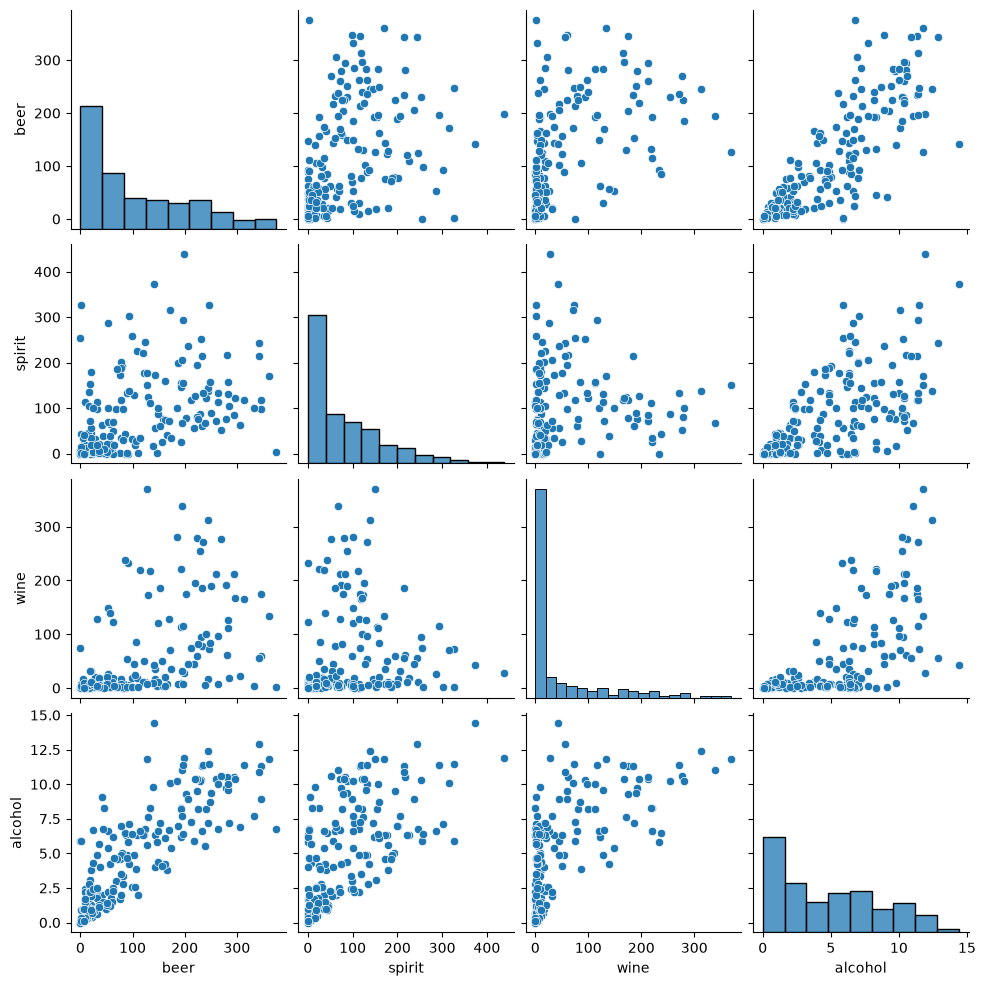

In [ ]:
#산점도 출력하기
# pairplot : 산점도 + 히스토그램
sns.pairplot(drinks[ncol],height=2.5)

In [82]:
#각 컬럼별 결측값의 갯수 조회하기
drinks.isnull().sum()

country       0
beer          0
spirit        0
wine          0
alcohol       0
continent    23
dtype: int64

In [83]:
# 대륙 컬럼의 결측값을 'OT'값으로 변경하기
# fillna(값)
drinks['continent'] = drinks['continent'].fillna('OT')

In [84]:
drinks.isnull().sum()

country      0
beer         0
spirit       0
wine         0
alcohol      0
continent    0
dtype: int64

In [86]:
# 대륙별 국가수 출력하기
#1
drinks.groupby('continent').count()['country']


continent
AF    53
AS    44
EU    45
OC    16
OT    23
SA    12
Name: country, dtype: int64

In [87]:
drinks['continent'].value_counts()

continent
AF    53
EU    45
AS    44
OT    23
OC    16
SA    12
Name: count, dtype: int64

Text(0.5, 1.0, "null data to 'OT'")

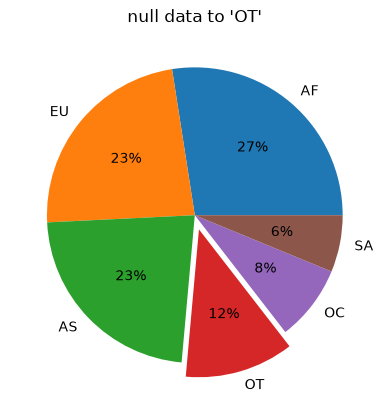

In [93]:
# 대륙별 국가의 갯수를 파이그래프로 출력하기
import matplotlib.pyplot as plt
#drinks["continent"].value_counts().index : 국가가 많은 순의 대륙코드
#tolist() : 리스트 객체로 리턴
labels = drinks["continent"].value_counts().index.tolist()
# ['AF', 'EU', 'AS', 'OT', 'OC', 'SA']
explode = (0,0,0,0.1,0,0) #파이조각의 위치 설정. labels의 갯수와 같아야 함
#plt.pie : 파이그래프
#autopct="%.0f%%" : 비율 데이터 출력. %.0f : 소숫점없음, %%: % 문자출력
#shadow=True : 그림자 표시
plt.pie(drinks["continent"].value_counts(),labels=labels,autopct="%.0f%%",\
        explode=explode,shadow=False)
plt.title("null data to 'OT'")

In [98]:
# 대륙별 splite 컬럼의 평균,최소,최대,합계출력하기
drinks.groupby('continent').spirit.mean()
drinks.groupby('continent').spirit.min()
drinks.groupby('continent').spirit.max()
drinks.groupby('continent').spirit.sum()
#4개의 함수 한번에 출력하기
drinks.groupby('continent').spirit.agg(['mean','min','max','sum'])

,mean,min,max,sum
continent,,,,
AF,16.339623,0,152,866
AS,60.840909,0,326,2677
EU,132.555556,0,373,5965
OC,58.437500,0,254,935
OT,165.739130,68,438,3812
SA,114.750000,25,302,1377


In [ ]:
# 전체 알콜섭취량의 평균보다 대륙의 평균이 높은 대륙을 출력하기
alcohol_tot_mean = drinks.alcohol.mean()
print(alcohol_tot_mean) #전체평균값
# 대륙별 평균값
continent_mean = drinks.groupby('continent')['alcohol'].mean()
print(continent_mean)
over_mean = continent_mean[continent_mean > alcohol_tot_mean]
print(over_mean.index.values)

In [ ]:
# 평균 맥주(beer)소비량이 가장 높은 대륙 출력하기
beer_mean = drinks.groupby('continent').beer.mean()
beer_mean
beer_mean.max() #최대값
beer_mean.idxmax() #최대값을 가진 데이터의 인덱스 리턴

'EU'

In [110]:
#맥주 평균 소비량이 가장 적은 대출 출력하기
beer_mean.idxmin() 

'AS'

Text(0.5, 1.0, 'total_litres_of_pure_alcohol by continent')

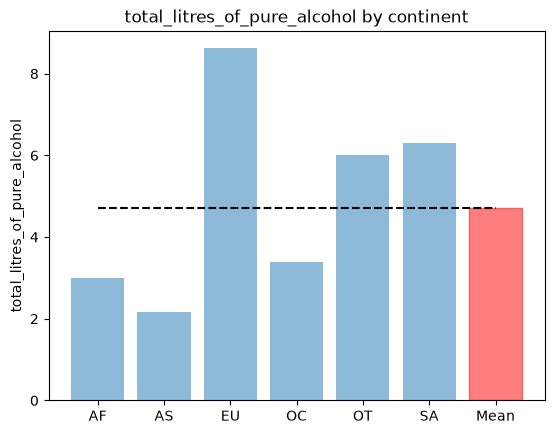

In [ ]:
#대륙별 알콜 섭취량 평균을 막대그래프로 출력하기
import numpy as np
cont_mean = drinks.groupby("continent").alcohol.mean() #대륙별 평균알콜 소비량
continents = cont_mean.index.tolist()  #대륙 코드
continents.append("Mean") # 대륙코드 + Mean 
x_pos = np.arange(len(continents)) # 0 ~ 6 배열
alcohol = cont_mean.tolist()  # 대륙별 평균 알콜 소비량 (6개데이터)

total_mean = drinks.alcohol.mean() # 전체 알콜 소비량
alcohol.append(total_mean)  # 대륙별 평균데이터 + 전체평균데이터
#plt.bar(x축의값,y축의값,막대위치정렬,투명도) : 막대그래프 출력 함수
bar_list = plt.bar(x_pos,alcohol,align='center',alpha=0.5) 
#bar_list[len(continents)-1] : 마지막 막대 그래프. 
bar_list[len(continents)-1].set_color("r") #색상을  red로 설정
#선그래프 (x축데이터, y축데이터)
#"k--" : 검정식 대쉬선 
plt.plot([0,6],[total_mean,total_mean],"k--") 
plt.xticks(x_pos,continents) 
plt.ylabel("total_litres_of_pure_alcohol")
plt.title("total_litres_of_pure_alcohol by continent")

Text(0.5, 1.0, 'beer_servings by Continent')

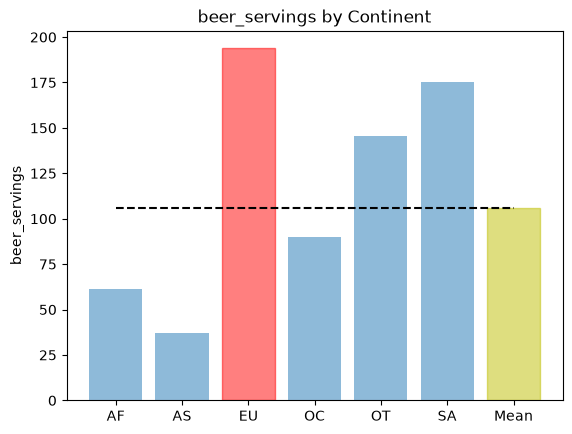

In [115]:
'''
대륙별 beer의 평균를 막대그래프로 시각화
가장 많은 맥주를 소비하는 EU 막대의 색상을 빨강색으로 변경하기 
전체 맥주 소비량 평균을 구해서 막대그래프에 추가
평균선을 출력하기. 막대 색상은 노랑색 
평균선은 검정색("k--")
'''
#대륙별 맥주 평균소비량
beer_mean = drinks.groupby("continent")["beer"].mean()
total_mean = drinks.beer.mean() 

continents = beer_mean.index.tolist()
continents.append("Mean")
x_pos = np.arange(len(continents))
beer = beer_mean.tolist()
beer.append(total_mean)
bar_list = plt.bar(x_pos, beer, align='center',alpha=0.5)
bar_list[2].set_color("r") 
bar_list[continents.index("Mean")].set_color("y")
plt.xticks(x_pos, continents) 
plt.plot([0.,6],[total_mean,total_mean],'k--') 
plt.ylabel('beer_servings')
plt.title('beer_servings by Continent')

In [ ]:
# 대한민국의 위치를 그래프로 구현하기
# 전체소비량 컬럼 추가 : beer + spirit + wine
# 알콜비율 = 알콜량 /전체소비량

#전체소비량 컬럼 추가하기
drinks['전체소비량'] = drinks['beer']+drinks['spirit']+drinks['wine']
drinks.head()
#alcohol_rate 컬럼 생성 : 순수알콜량 / 전체소비량 
# 값이 크면 : 독주위주, 값이작으면 : 약한술 위주
# 결측값 생성 : 0으로 나눌때 결측값
drinks['alcohol_rate'] = drinks['alcohol'] / drinks['전체소비량']
drinks.info()

In [120]:
#drinks['alcohol_rate'] 결측값 0으로 변경하기
drinks['alcohol_rate'] = drinks['alcohol_rate'].fillna(0)
drinks.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       193 non-null    str    
 1   beer          193 non-null    int64  
 2   spirit        193 non-null    int64  
 3   wine          193 non-null    int64  
 4   alcohol       193 non-null    float64
 5   continent     193 non-null    str    
 6   전체소비량         193 non-null    int64  
 7   alcohol_rate  193 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 12.2 KB


In [123]:
# 나라정보와 알콜비율데이터만 가진 데이터 생성
alcohol_rank = drinks[['country','alcohol_rate']]
alcohol_rank.head()
#alcohol_rank 내림차순 정렬하기
alcohol_rank = alcohol_rank.sort_values(by='alcohol_rate',ascending=False)
alcohol_rank.head(20)

,country,alcohol_rate
63,Gambia,0.266667
153,Sierra Leone,0.223333
124,Nigeria,0.185714
179,Uganda,0.153704
142,Rwanda,0.151111
183,Tanzania,0.132558
26,Burkina Faso,0.110256
33,Central African Republic,0.090000
28,Cote d'Ivoire,0.088889
104,Mali,0.085714


['Gambia', 'Sierra Leone', 'Nigeria', 'Uganda', 'Rwanda', 'Tanzania', 'Burkina Faso', 'Central African Republic', "Cote d'Ivoire", 'Mali', 'Sudan', 'Malawi', 'Burundi', 'DR Congo', 'South Korea', 'Zimbabwe', 'Swaziland', 'Zambia', 'Ghana', 'Cameroon']


Text(24, 0.1093939393939394, 'South Korea : 15번째')

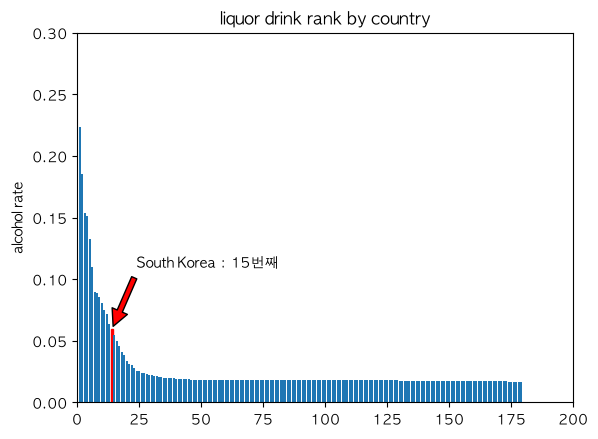

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc("font",family="AppleGothic") 
country_list = alcohol_rank.country.tolist()
print(country_list[:20])

x_pos = np.arange(len(country_list))

rank = alcohol_rank.alcohol_rate.tolist()
country_list.index("South Korea") 
bar_list = plt.bar(x_pos, rank) 

#country_list.index("South Korea") : 남한의 막대그래프의 위치
bar_list[country_list.index("South Korea")].set_color('r')
plt.ylabel('alcohol rate')
plt.title('liquor drink rank by country')

# x축값: 0 ~ 200
# y축의값 : 0 ~ 0.3
plt.axis([0, 200, 0, 0.3])
korea_rank = country_list.index("South Korea") #14

test = alcohol_rank[alcohol_rank['country']=='South Korea']
test["alcohol_rate"].values[0]

korea_alc_rate = alcohol_rank[alcohol_rank['country'] == 'South Korea']\
    ['alcohol_rate'].values[0]
'''
 xy : 화살표 위치 지정 
'''
plt.annotate('South Korea : ' + str(korea_rank + 1)+"번째", 
            xy=(korea_rank, korea_alc_rate), 
            xytext=(korea_rank + 10, korea_alc_rate + 0.05),  #텍스트의 출력 위치값
            arrowprops=dict(facecolor='red', shrink=0.05))